## Hexbin ratio map generation from pS6 and RBPMS images

This script generates spatial hexbin ratio maps from pS6 and RBPMS retinal images in order to visualise the relative pS6 signal across the RBPMS-positive population while preserving retinal context. The workflow begins with TIFF stacks that were first cropped to the retina in Fiji/ImageJ using **Clear Outside** and then imported into Python as single-channel images. RBPMS-positive pixels are segmented to define the RGC mask, while a separate tissue mask is generated from the pS6 image to represent the surrounding retinal region outside the segmented RGC population.

The main steps in this workflow are: generation of the RBPMS-positive mask, generation of the tissue mask, per-channel background estimation and subtraction, hexbin-based spatial aggregation, and construction of a per-bin ratio map defined as **mean(pS6) / mean(RBPMS)**. The tissue mask is then rendered as a constant low-intensity background layer so that the final ratio map retains anatomical context instead of appearing as an isolated signal-only plot.

When repeating this analysis, the parameters most likely to require adjustment are the percentile thresholds used for RBPMS and tissue segmentation, the minimum connected-component sizes used during mask cleanup. These settings should be reviewed carefully for each dataset, especially if staining quality, signal intensity, or image resolution differ between samples. All display settings used for the final map, including the colormap, the fixed intensity range and the **gridsize** should remain consistent across samples if direct visual comparison is intended.

### Required packages

This section installs and imports the packages needed for image loading, processing, and plotting. If a package is missing, install it first, then run the imports below.

```bash
pip install tifffile numpy matplotlib scipy
```

In [2]:
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import scipy.ndimage as ndi

### Loading of cropped pS6 and RBPMS TIFF images

In this section, the cropped TIFF exported from Fiji/ImageJ are loaded into Python and converted into single-channel 2D images for subsequent analysis. Before this step, each image should already be restricted to the retinal region (no lens) using the **Clear Outside** function in Fiji/ImageJ. The pS6 and RBPMS images should correspond to the same sample and should have matching dimensions.

When repeating the analysis, only the file paths generally need to be updated in this section. After loading, the images should be visually inspected to confirm that cropping was performed correctly, that the retinal region is intact, and that the two channels are spatially aligned.

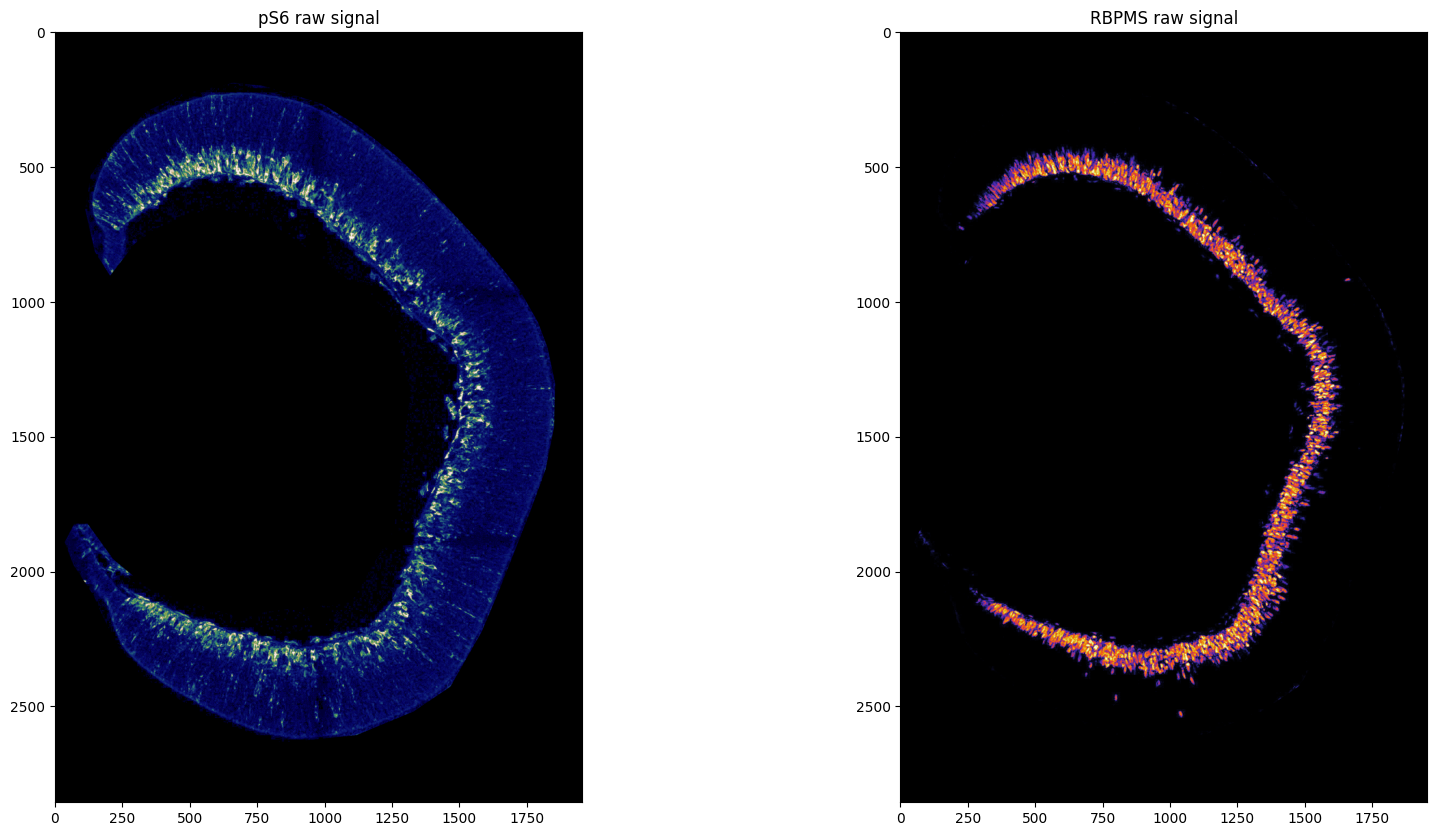

In [3]:
# Load pS6
# Change this path to the pS6 TIFF file for the current sample
with tiff.TiffFile("./cleared_image_example/E18_pS6_cleared.tif") as tif:
    pS6 = tif.series[0].asarray()  

# Load RBPMS
# Change this path to the matching RBPMS TIFF file for the same sample
with tiff.TiffFile("./cleared_image_example/E18_RBPMS_cleared.tif") as tif:
    RBPMS = tif.series[0].asarray()
        
Img_RBPMS = np.max(RBPMS, axis=2) # to delete color channel dependency
Img_pS6 = np.max(pS6, axis = 2) # to delete color channel dependency


plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(Img_pS6, cmap="gist_earth")
plt.title("pS6 raw signal")

plt.subplot(1, 2, 2)
plt.imshow(Img_RBPMS, cmap="CMRmap")
plt.title("RBPMS raw signal")

plt.show()

### Segmentation of RBPMS-positive pixels and generation of the tissue mask

This section defines the binary masks used for ratio-map generation. RBPMS-positive pixels are segmented from the RBPMS image by Gaussian smoothing, percentile thresholding, hole filling, morphological opening, and connected-component filtering. A separate tissue mask is generated from the pS6 image using the same general workflow, followed by removal of RBPMS-positive pixels so that the final tissue mask represents retinal context outside the segmented RGC population.

The parameters most likely to require adjustment when repeating the experiment are the percentile thresholds and minimum connected-component sizes. Higher thresholds produce more conservative masks, whereas lower thresholds include more weak signal and potentially more background. The resulting masks should always be inspected visually before continuing, as this stage determines the quality and interpretability of all downstream ratio maps.

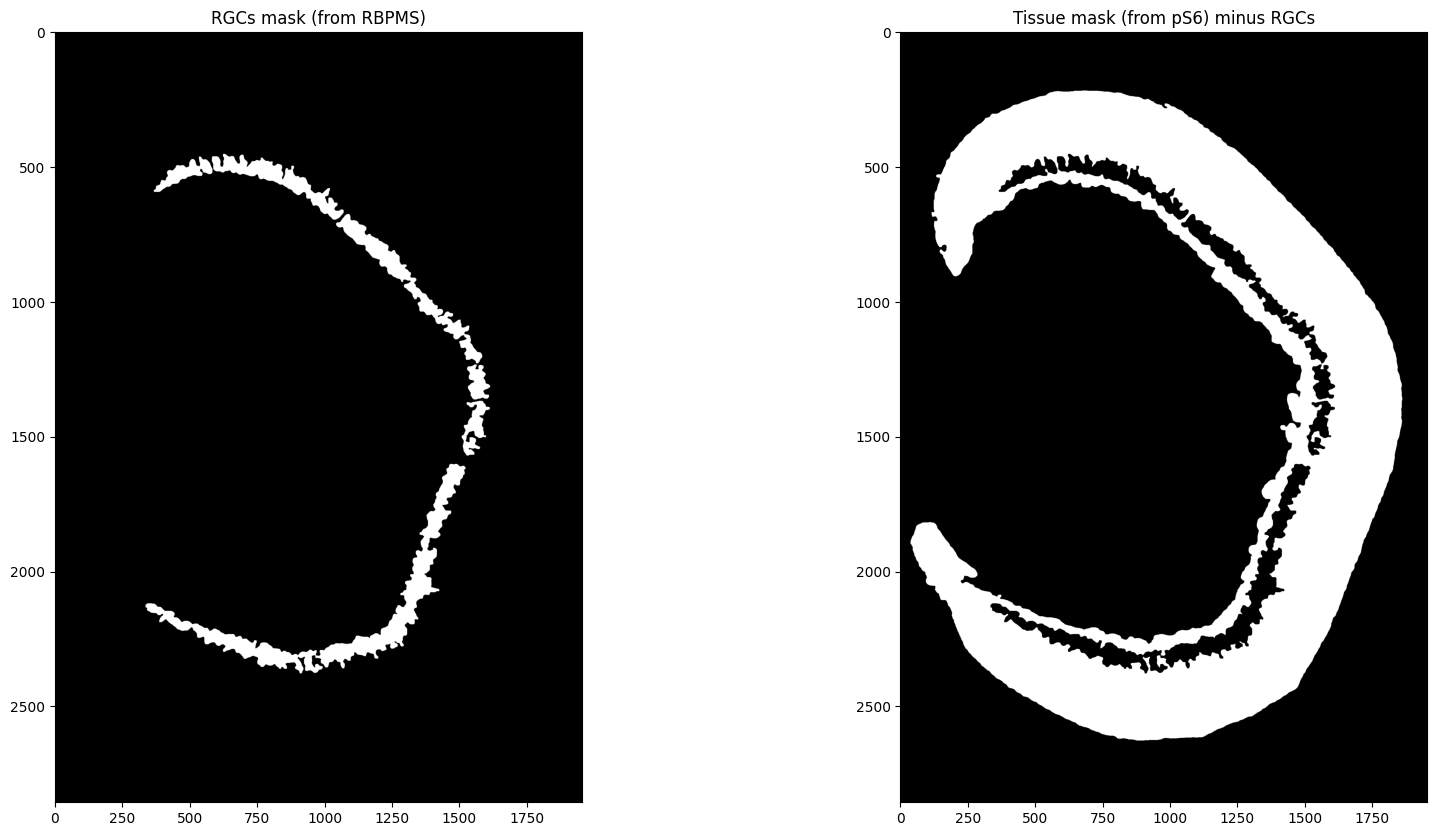

In [4]:
percentile1 = 96.6  # RGCs (RBPMS)
percentile2 = 50   # Tissue (pS6)
size1 = 2000 # RGCs (RBPMS)
size2 = 20000 # Tissue (pS6)

mip_smooth_r = gaussian_filter(Img_RBPMS, sigma=5)
thr1 = np.percentile(mip_smooth_r, percentile1)

rgcs_mask = mip_smooth_r > thr1
rgcs_mask = ndi.binary_fill_holes(rgcs_mask)
rgcs_mask = ndi.binary_opening(rgcs_mask, structure=np.ones((7, 7)))
rgcs_mask = ndi.label(rgcs_mask)[0]
sizes = np.bincount(rgcs_mask.ravel())
for lab in np.where(sizes < size1)[0]:
    rgcs_mask[rgcs_mask == lab] = 0
rgcs_mask = (rgcs_mask > 0)


mip_smooth_t = gaussian_filter(Img_pS6, sigma=5)
thr2 = np.percentile(mip_smooth_t, percentile2)

tissue_mask = mip_smooth_t > thr2
tissue_mask = ndi.binary_fill_holes(tissue_mask)
tissue_mask = ndi.binary_opening(tissue_mask, structure=np.ones((7, 7)))
tissue_mask = ndi.label(tissue_mask)[0]
sizes = np.bincount(tissue_mask.ravel())
for lab in np.where(sizes < size2)[0]:
    tissue_mask[tissue_mask == lab] = 0
tissue_mask = (tissue_mask > 0)

tissue_mask = tissue_mask & (~rgcs_mask)

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(rgcs_mask, cmap="gray");  ax[0].set_title("RGCs mask (from RBPMS)")
ax[1].imshow(tissue_mask, cmap="gray"); ax[1].set_title("Tissue mask (from pS6) minus RGCs")
plt.show()

### Background estimation and subtraction

In this section, background intensity is estimated separately for each channel from the tissue mask after exclusion of RBPMS-positive pixels. The median intensity within this mask is used as the per-channel background estimate. This value is subtracted from the full image, and negative values are clipped to zero prior to hexbin aggregation.

In [5]:
background_mask = tissue_mask

background_pixels_pS6  = Img_pS6[background_mask]
background_pixels_RGCS = Img_RBPMS[background_mask]

background_median_pS6  = np.median(background_pixels_pS6)
background_median_RGCS = np.median(background_pixels_RGCS)

print('background_median_pS6', background_median_pS6)
print('background_median_RGCS', background_median_RGCS)

Img_pS6_bgsub = Img_pS6 - background_median_pS6
Img_RBPMS_bgsub = Img_RBPMS - background_median_RGCS

background_median_pS6 7.0
background_median_RGCS 0.0


### Hexbin-based spatial aggregation and ratio calculation

This final part computes the spatial ratio map by applying hexagonal binning to pixels belonging to the RBPMS-positive mask. Within each bin, the mean pS6 signal and mean RBPMS signal are computed independently, and the final bin value is defined as the ratio between them. Bins with zero mean RBPMS are excluded from the analysis. In the background the tissue mask is rendered as a constant background layer in order to preserve retinal context, and the computed ratio map is overlaid using a fixed colormap and fixed display range. This allows spatial interpretation of the ratio values while retaining the overall retinal outline. The resulting figure is exported in vector format as both PDF and SVG.

When repeating the experiment, display settings such as the colormap, gridsize,  fixed intensity range, and background layer value should remain consistent if visual comparison across samples is desired. The exported output should be checked to confirm that retinal context is preserved and that the overlay remains clean and interpretable.

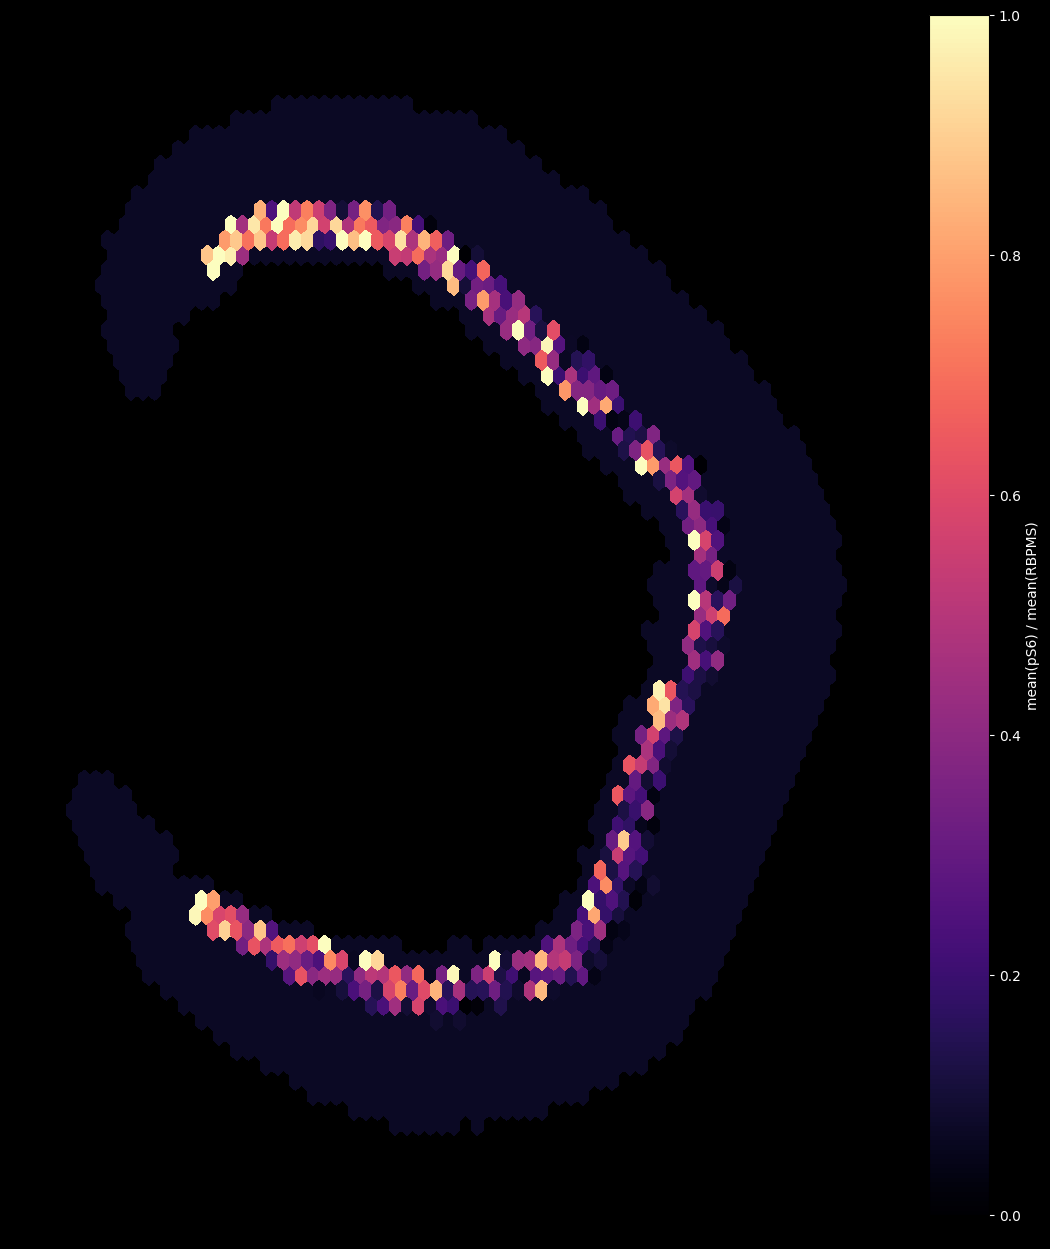

In [6]:
color = "magma"
gridsize = 70
bg_ratio = 0.07

if Img_pS6_bgsub.shape != Img_RBPMS_bgsub.shape:
    raise ValueError("Images must have same shape.")
Y, X = Img_pS6_bgsub.shape
extent_xy = (0, X, 0, Y)


ys, xs = np.indices((Y, X))
xs, ys = xs.ravel(), ys.ravel()

tissue = tissue_mask.ravel() > 0
rgc    = rgcs_mask.ravel() > 0

xs_t, ys_t = xs[tissue], ys[tissue]
xs_r, ys_r = xs[rgc],    ys[rgc]

pS6_r  = Img_pS6_bgsub.ravel()[rgc]
RBPS_r = Img_RBPMS_bgsub.ravel()[rgc]

fig, ax = plt.subplots(figsize=(12, 12), facecolor="black")
ax.set_facecolor("black")

hb_ps6 = ax.hexbin(xs_r, ys_r, C=pS6_r, gridsize=gridsize, extent=extent_xy,
                   reduce_C_function=np.mean, cmap=color, alpha=0)
hb_RBPS = ax.hexbin(xs_r, ys_r, C=RBPS_r, gridsize=gridsize, extent=extent_xy,
                    reduce_C_function=np.mean, cmap=color, alpha=0)


m1, m2 = hb_ps6.get_array(), hb_RBPS.get_array()
ratio = np.full(m1.shape, np.nan, float)
ok = (m2 != 0)
ratio[ok] = m1[ok] / m2[ok]

hb_ps6.remove()
hb_RBPS.remove()

hb_bg = ax.hexbin(
    xs_t, ys_t,
    C=np.full(xs_t.size, bg_ratio),
    gridsize=gridsize, extent=extent_xy,
    reduce_C_function=np.mean, cmap=color,
    linewidths=0, edgecolors="none", antialiased=False
)
hb_bg.set_clim(0, 1)
hb_bg.set_zorder(1)

hb_ratio = ax.hexbin(
    xs_r, ys_r,
    C=np.ones_like(pS6_r, float),
    gridsize=gridsize, extent=extent_xy,
    reduce_C_function=np.mean, cmap=color,
    linewidths=0, edgecolors="none", antialiased=False
)
hb_ratio.set_array(ratio)
hb_ratio.set_clim(0, 1)
hb_ratio.set_zorder(2)

ax.set_xlim(0, X)
ax.set_ylim(Y, 0)
ax.set_aspect("equal", adjustable="box")
fig.subplots_adjust(left=0, right=0.88, bottom=0, top=1)

cbar = fig.colorbar(hb_ratio, ax=ax, label="mean(pS6) / mean(RBPMS)")
cbar.ax.yaxis.set_tick_params(color="white"); plt.setp(cbar.ax.get_yticklabels(), color="white")
cbar.set_label("mean(pS6) / mean(RBPMS)", color="white")

fig.savefig("Hexbin_map.pdf", facecolor=fig.get_facecolor())
fig.savefig("Hexbin_map.svg", facecolor=fig.get_facecolor())
plt.show()